In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [2]:
data = pd.read_csv("E:\Dissertation\MaliciousURLsTransformed.csv")

In [3]:
x = data.drop(columns=['url_type'])
y = data['url_type'] 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=42)

In [4]:

print(f"X_train Shape : {x_train.shape}")
print(f"Y_train Shape : {y_train.shape}")
print(f"X_test  Shape : {x_test.shape}")
print(f"Y_test  Shape : {y_test.shape}")

X_train Shape : (709194, 19)
Y_train Shape : (709194,)
X_test  Shape : (303941, 19)
Y_test  Shape : (303941,)


Model => DecisionTreeClassifier 
Test Accuracy:  98.84%  
              Classification Report 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    230584
           1       0.98      0.98      0.98     73357

    accuracy                           0.99    303941
   macro avg       0.98      0.98      0.98    303941
weighted avg       0.99      0.99      0.99    303941

             Confusion Matrix 


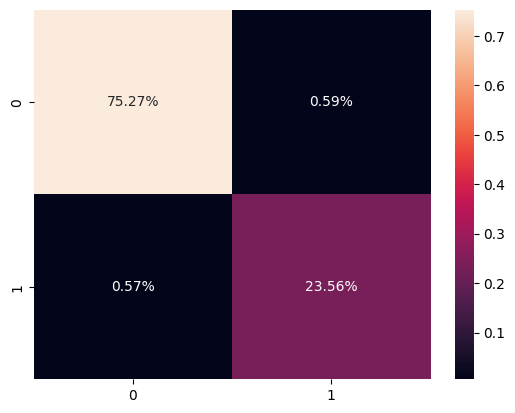

###################- End -###################
Model => RandomForestClassifier 


KeyboardInterrupt: 

In [6]:
models = [
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    AdaBoostClassifier(),
    KNeighborsClassifier(),
    ExtraTreesClassifier(),
    GaussianNB(),
    LogisticRegression(), 
    SGDClassifier()
]

results = []

for model in models:
    print('Model => {} '.format(type(model).__name__))
    
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    f1_score = report['macro avg']['f1-score']
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    results.append({
        'Model': type(model).__name__,
        'Accuracy': accuracy,
        'F1-Score': f1_score,
        'Precision': precision,
        'Recall': recall
    })
    
    print('Test Accuracy:\033[32m \033[01m {:.2f}% \033[30m \033[0m'.format(accuracy * 100))
    print('\033[01m              Classification Report \033[0m')
    print(classification_report(y_test, y_pred))
    print('\033[01m             Confusion Matrix \033[0m')
    cf_matrix = confusion_matrix(y_test, y_pred)
    plot_ = sns.heatmap(cf_matrix / np.sum(cf_matrix), annot=True, fmt='0.2%')
    plt.show()
    print('###################- End -###################')

In [ ]:
models_report = pd.DataFrame(results)
models_report.head()

In [ ]:
import plotly.graph_objects as go

# Create the Plotly figure
fig = go.Figure(data=go.Table(
    header=dict(values=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
                fill_color='black',
                font=dict(color='white'),
                align='center'),
    cells=dict(values=[models_report['Model'], models_report['Accuracy'], models_report['Precision'],
                       models_report['Recall'], models_report['F1-Score']],
               fill_color='black',
               font=dict(color='white'),
               align='center')))

# Update layout for dark background and white font
fig.update_layout(
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white'))

# Display the plot
fig.show()

In [ ]:
import plotly.graph_objects as go

# Iterate over the columns of models_report DataFrame
for column in models_report.columns:
    # Create a Plotly figure for each column
    fig = go.Figure(data=go.Bar(
        x=models_report['Model'],
        y=models_report[column],
        marker=dict(color='steelblue'),
        text=models_report[column],
        textposition='auto'
    ))

    # Set the chart title and axis labels
    fig.update_layout(
        title_text=column,
        xaxis_title='Model',
        yaxis_title=column,
        plot_bgcolor='rgb(17,17,17)',  # Dark background color
        paper_bgcolor='rgb(17,17,17)',  # Dark background color
        font=dict(color='white')  # White font color
    )

    # Display the chart
    fig.show()
